U =
[[0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]]
Is U unitary?
True
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


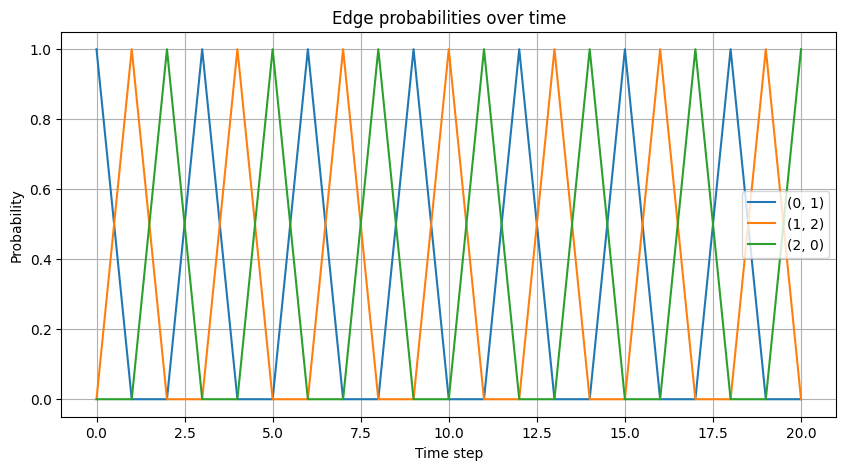

True
Is U2 unitary?
True


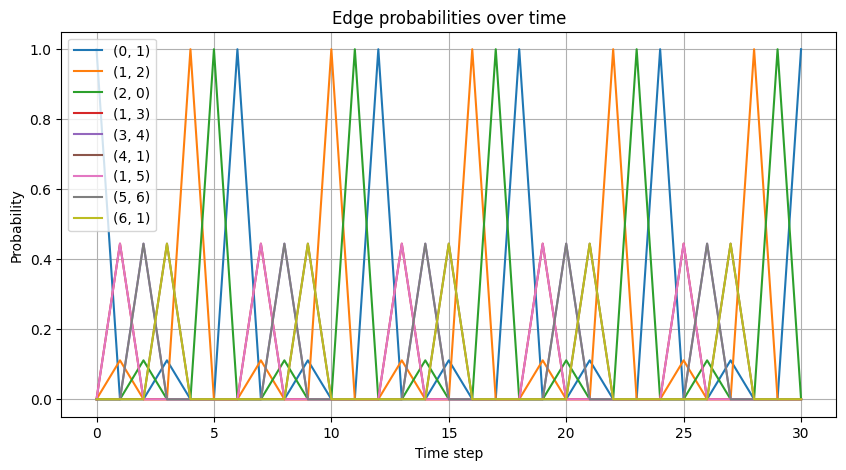

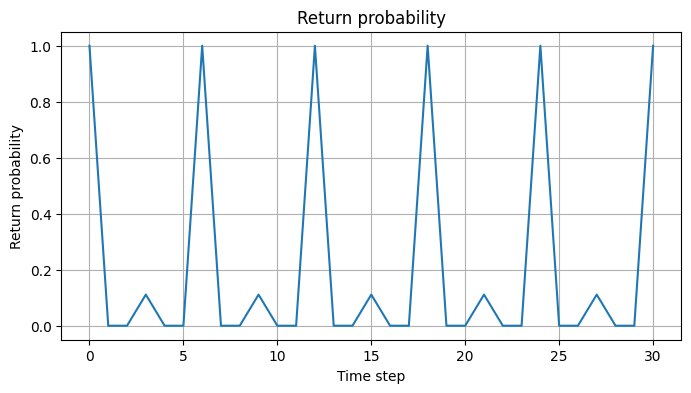

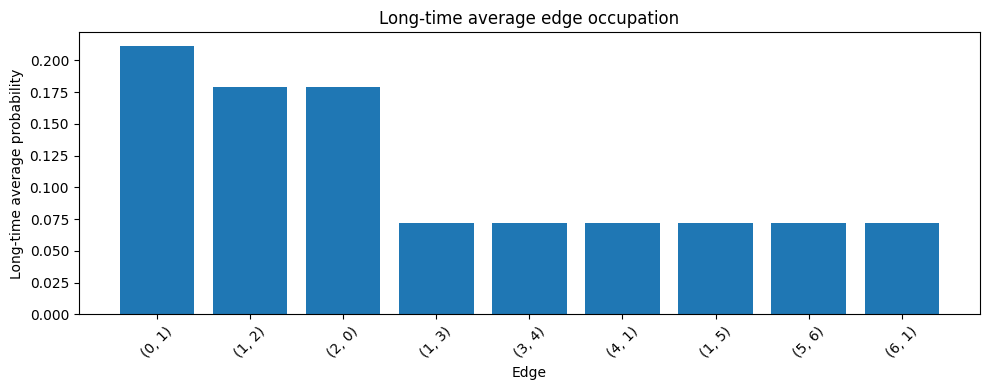

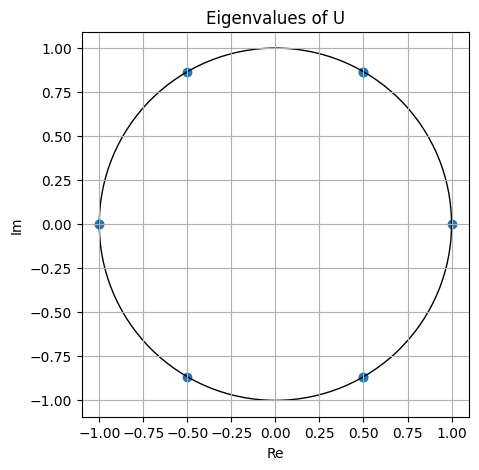

[ 1. +0.j        -0.5+0.8660254j -0.5-0.8660254j  0.5+0.8660254j
  0.5-0.8660254j  0.5+0.8660254j  0.5-0.8660254j -1. +0.j
 -1. +0.j       ]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def grover_coin(d):
    """
    Return the d x d Grover diffusion coin.
    """
    if d == 1:
        return np.array([[1.0]], dtype=complex)     # 1x1 matrix for dv=1

    J = np.ones((d, d), dtype=complex)              # matrix of all ones of size dv x dv
    I = np.eye(d, dtype=complex)                    # identity matrix of size dv x dv
    return (2 / d) * J - I                          # Grover coin formula


def check_eulerian(edges):
    """
    Check whether a directed graph is Eulerian.
    edges is a list of tuples: [(u,v), ...]
    """
    indeg = defaultdict(int)                        # in-degree of each vertex with key as source vertex, value as target vertex
    outdeg = defaultdict(int)                       # out-degree of each vertex with key as source vertex, value as target vertex
    vertices = set()                                # set of all vertices in the graph

    for u, v in edges:                              # tuple-unpacking for each edge (u,v) in edges
        outdeg[u] += 1
        indeg[v] += 1
        vertices.add(u)
        vertices.add(v)

    for v in vertices:
        if indeg[v] != outdeg[v]:                   # false, if in-degree and out-degree of any vertex are not equal
            return False

    return True


def build_eulerian_walk_operator(edges):                       
    """
    Build the edge-based Eulerian quantum walk operator U.

    Basis states are directed edges.
    Each incoming edge to a vertex scatters into outgoing edges from that vertex.
    """
    if not check_eulerian(edges):
        raise ValueError("Graph is not Eulerian.")

    edge_to_index = {e: i for i, e in enumerate(edges)}        # i = u, edge_to_index = [0,1,2] for three edges = [(0,1), (1,2), (2,0)]
                                                                # {(0,1) : 0, (1,2) : 1, (2,0): 2}
    n_edges = len(edges) # 3

    incoming = defaultdict(list)
    outgoing = defaultdict(list)

    for e in edges:
        u, v = e
        outgoing[u].append(e) # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]
        incoming[v].append(e) # incoming[1] = [(0,1)], incoming[2] = [(1,2)], incoming[0] = [(2,0)]

    U = np.zeros((n_edges, n_edges), dtype=complex) # global unitary matrix of size e x e

    vertices = set()
    for u, v in edges:
        vertices.add(u)
        vertices.add(v)     # vertices = {0, 1, 2} 

    for v in vertices:
        in_edges = incoming[v] # incoming[0] = [(2,0)], incoming[1] = [(0,1)], incoming[2] = [(1,2)]
        out_edges = outgoing[v]    # outgoing[0] = [(0,1)], outgoing[1] = [(1,2)], outgoing[2] = [(2,0)]

        d = len(in_edges) # d = 1
        C = grover_coin(d) # make 1x1 matrix of val [1.0]

        for i, e_in in enumerate(in_edges):
            for j, e_out in enumerate(out_edges):
                row = edge_to_index[e_out] # edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1, edge_to_index[(2,0)] = 2
                col = edge_to_index[e_in] # edge_to_index[(2,0)] = 2, edge_to_index[(0,1)] = 0, edge_to_index[(1,2)] = 1
                U[row, col] = C[j, i] # U[0,2] = C[0,0] = 1.0 when v = 0,
                                      # U[1,0] = C[0,0] = 1.0 when v = 1, U[2,1] = C[0,0] = 1.0 when v = 2

    return U, edge_to_index # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}

edges = [
    (0, 1),
    (1, 2),
    (2, 0)
]

U, edge_to_index = build_eulerian_walk_operator(edges) # U = [[0, 0, 1], [1, 0, 0], [0, 1, 0]], edge_to_index = {(0,1): 0, (1,2): 1, (2,0): 2}

print("U =") 
print(U) # verified

print("Is U unitary?")
print(np.allclose(U.conj().T @ U, np.eye(len(edges))))

def simulate_walk(U, start_edge_index, T):
    """
    Simulate psi(t+1) = U psi(t).
    """
    n = U.shape[0] # n = 3 for three edges, gives you the number of rows which is the dimension of the Hilbert space which contains one basis state for each edge 

    # |e1> = (1,0,0), |e2> = (0,1,0), |e3> = (0,0,1)
    # hilbert space is spanned by the basis states corresponding to the edges, so n = 3

    psi = np.zeros(n, dtype=complex) # creates a complex 1D array of zeroos off length 3
    psi[start_edge_index] = 1.0 # whatever edge it starts at psi would be of the form either |e1>, |e2>, |e3>

    states = []

    for t in range(T + 1): # T is the no. of time steps
        states.append(psi.copy())
        psi = U @ psi

    return np.array(states)

T = 20
start_edge = (0, 1)
start_index = edge_to_index[start_edge] # {(0,1): 0, (1,2): 1, (2,0): 2} [(0,1)] = 0

states = simulate_walk(U, start_index, T) # (T+1)xn matrix with starting with where walker is and then multiplication of U @ psi where it moves next.
                                        # states is a list of T+1 elements with size n.

probabilities = np.abs(states) ** 2

print(probabilities) # probabilities is a list of T+1 elements with size n with absolute vaue of elements of states squared

def plot_edge_probabilities(probabilities, edges):
    T = probabilities.shape[0] # finds the nummber of time steps by seeing the no. of rows in probabilities

    plt.figure(figsize=(10, 5))

    for i, e in enumerate(edges):       # i = 0,1,2, e = e1,e2,e3
        plt.plot(range(T), probabilities[:, i], label=str(e))

    plt.xlabel("Time step")
    plt.ylabel("Probability")
    plt.title("Edge probabilities over time")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_edge_probabilities(probabilities, edges)

edges2 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1)
] # if d is limited to 2 then we don't have a split, and if there are more dependencies or loops then there will be complex terms and a split

print(check_eulerian(edges2))

U2, edge_to_index2 = build_eulerian_walk_operator(edges2)

print("Is U2 unitary?")
print(np.allclose(U2.conj().T @ U2, np.eye(len(edges2))))

T = 30
start_edge = (0, 1)
start_index = edge_to_index2[start_edge]

states2 = simulate_walk(U2, start_index, T)
probabilities2 = np.abs(states2) ** 2

plot_edge_probabilities(probabilities2, edges2)

def return_probability(probabilities, start_edge_index):
    return probabilities[:, start_edge_index]


def plot_return_probability(probabilities, start_edge_index):
    P_return = return_probability(probabilities, start_edge_index)

    plt.figure(figsize=(8, 4))
    plt.plot(range(len(P_return)), P_return)
    plt.xlabel("Time step")
    plt.ylabel("Return probability")
    plt.title("Return probability")
    plt.grid(True)
    plt.show()

plot_return_probability(probabilities2, start_index)

def long_time_average(probabilities):
    return np.mean(probabilities, axis=0)


def plot_long_time_average(probabilities, edges):
    avg = long_time_average(probabilities)

    labels = [str(e) for e in edges]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, avg)
    plt.xlabel("Edge")
    plt.ylabel("Long-time average probability")
    plt.title("Long-time average edge occupation")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_long_time_average(probabilities2, edges2) # long-time average is the average probability of being on each edge over all time steps, which gives us insight into the steady-state distribution of the quantum walk.

def plot_spectrum(U): # the spectrum of a unitary operator is the set of its eigenvalues, which lie on the unit circle in the complex plane. 
    eigvals = np.linalg.eigvals(U)

    plt.figure(figsize=(5, 5))
    plt.scatter(eigvals.real, eigvals.imag)

    circle = plt.Circle((0, 0), 1, fill=False)
    plt.gca().add_artist(circle)

    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.title("Eigenvalues of U")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

    return eigvals

eigvals2 = plot_spectrum(U2)
print(eigvals2)

True
Is U3 unitary?
True


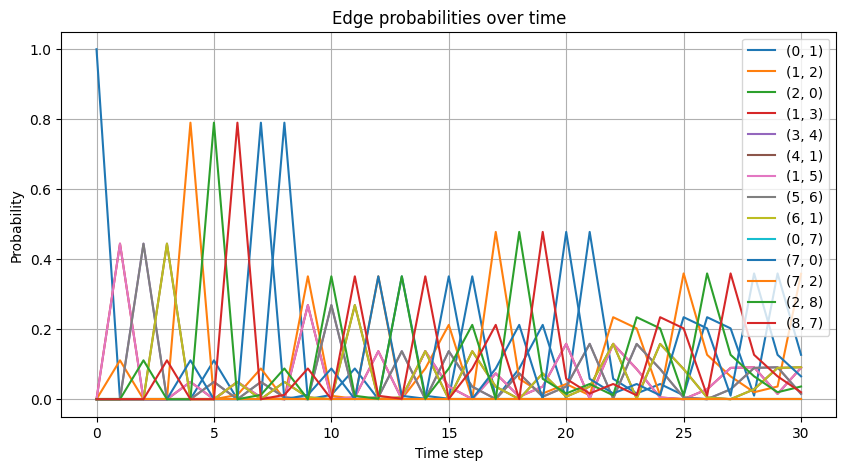

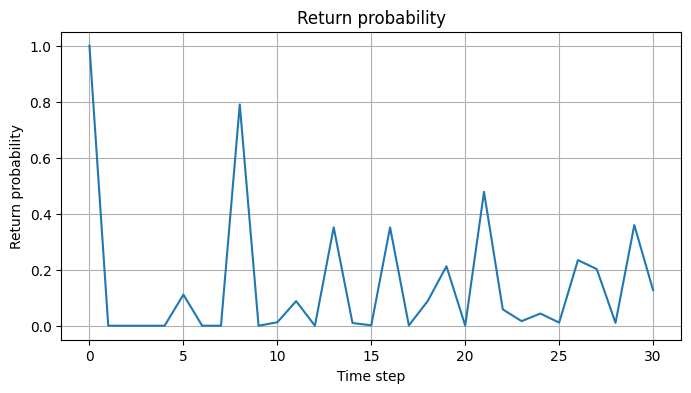

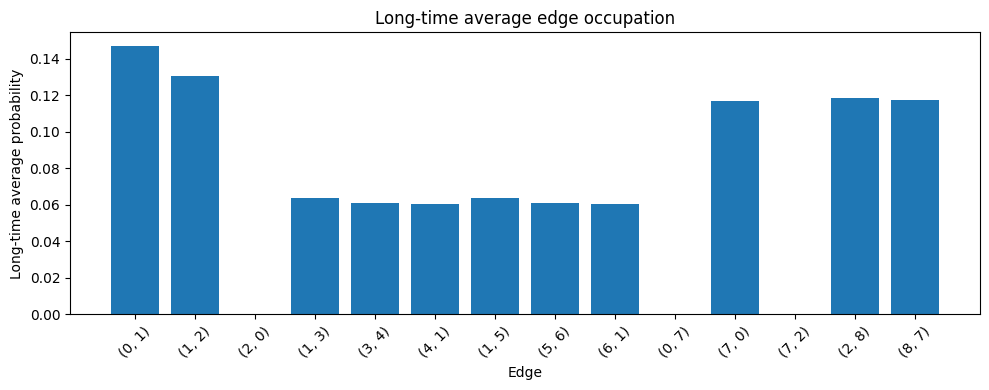

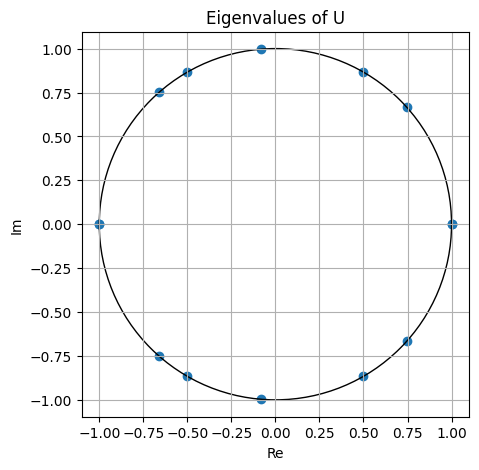

[ 0.74557704+6.66419443e-01j -0.08454183+9.96419931e-01j
  0.74557704-6.66419443e-01j -0.66103521+7.50354880e-01j
 -0.08454183-9.96419931e-01j -0.66103521-7.50354880e-01j
  1.        -1.11010240e-16j  0.5       +8.66025404e-01j
  1.        +1.52655666e-16j -0.5       +8.66025404e-01j
 -1.        +3.65830626e-16j -1.        +1.21723545e-16j
  0.5       -8.66025404e-01j -0.5       -8.66025404e-01j]


In [ ]:
edges3 = [
    (0, 1),
    (1, 2),
    (2, 0),

    (1, 3),
    (3, 4),
    (4, 1),

    (1,5),
    (5,6),
    (6,1),

    (0,7),
    (7,0),
    (7,2),
    (2,8),
    (8,7)
]

print(check_eulerian(edges3))

U3, edge_to_index3 = build_eulerian_walk_operator(edges3)

print("Is U3 unitary?")
print(np.allclose(U3.conj().T @ U3, np.eye(len(edges3))))

T = 30
start_edge = (0, 1)
start_index = edge_to_index3[start_edge]

states3 = simulate_walk(U3, start_index, T)
probabilities3 = np.abs(states3) ** 2

plot_edge_probabilities(probabilities3, edges3)

plot_return_probability(probabilities3, start_index)

plot_long_time_average(probabilities3, edges3)

eigvals3 = plot_spectrum(U3)
print(eigvals3)